# SHAP for the distilled listener

What each feature contributes to the GBT's score for a board word, on held-out
boards (gpt-oss teacher, 25% of board seeds never seen in training).

**Read these as scores, not probabilities.** The model is a conditional logit:
it emits one raw score per candidate word and a softmax *over the whole board*
turns those into probabilities. SHAP explains the raw score, which has no
meaning on its own -- only relative to the other words competing in the same
group. A +0.5 SHAP value means "this feature pushed this word half a logit
ahead of where it would otherwise have sat against its rivals".

Model: `cache/listener_gbt.txt` (177 trees, swept params).
Data: `cache/listener_val.npz`, precomputed so this notebook does not rebuild
features (~4 min).

In [1]:
%matplotlib inline
import numpy as np, lightgbm as lgb, shap, matplotlib.pyplot as plt

d = np.load("../cache/listener_val.npz", allow_pickle=False)
X, y, groups, step = d["X"], d["y"], d["groups"], d["step"]
names = [str(n) for n in d["names"]]
bst = lgb.Booster(model_file="../cache/listener_gbt.txt")

print(f"{X.shape[0]:,} rows x {X.shape[1]} features, {len(groups):,} choice events")
print(f"{bst.num_trees()} trees")

/home/maste/CodenamesAI/.venv/lib/python3.12/site-packages/numba/core/config.py:187: RuntimeWarning: Environment variable 'NUMBA_CUDA_USE_NVIDIA_BINDING' is defined but its associated value '1export' could not be parsed.
The parse failed with exception:
Traceback (most recent call last):
  File "/home/maste/CodenamesAI/.venv/lib/python3.12/site-packages/numba/core/config.py", line 185, in _readenv
    return ctor(value)
           ^^^^^^^^^^^
ValueError: invalid literal for int() with base 10: '1export'

  warnings.warn(f"Environment variable '{name}' is defined but "
/home/maste/CodenamesAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


224,506 rows x 36 features, 15,766 choice events
200 trees


## Compute

Subsampled to 40k rows; SHAP on trees is exact, so this is purely about plot
density and runtime, not accuracy of the attributions.

In [2]:
rng = np.random.default_rng(0)
idx = rng.choice(len(X), size=min(40_000, len(X)), replace=False)
Xs = X[idx]

explainer = shap.TreeExplainer(bst)
sv = explainer.shap_values(Xs)
print("shap values:", sv.shape, " base value:", round(float(explainer.expected_value), 4))

shap values: (40000, 36)  base value: -0.7224


## Global importance — mean |SHAP|

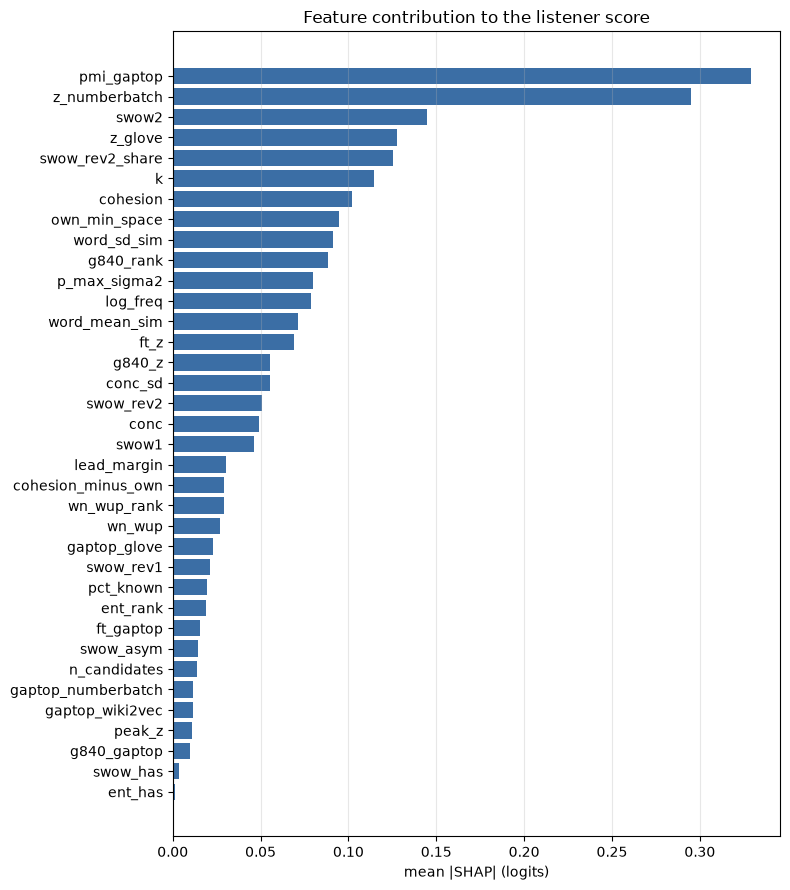

  pmi_gaptop             0.3292
  z_numberbatch          0.2951
  swow2                  0.1447
  z_glove                0.1276
  swow_rev2_share        0.1251
  k                      0.1147
  cohesion               0.1019
  own_min_space          0.0948
  word_sd_sim            0.0911
  g840_rank              0.0883
  p_max_sigma2           0.0799
  log_freq               0.0786
  word_mean_sim          0.0715
  ft_z                   0.0691
  g840_z                 0.0553
  conc_sd                0.0552
  swow_rev2              0.0506
  conc                   0.0494
  swow1                  0.0462
  lead_margin            0.0305
  cohesion_minus_own     0.0294
  wn_wup_rank            0.0290
  wn_wup                 0.0272
  gaptop_glove           0.0226
  swow_rev1              0.0215
  pct_known              0.0195
  ent_rank               0.0189
  ft_gaptop              0.0155
  swow_asym              0.0142
  n_candidates           0.0141
  gaptop_numberbatch     0.0118
  gaptop

In [3]:
mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh([names[i] for i in order], mean_abs[order], color="#3b6ea5")
ax.set_xlabel("mean |SHAP| (logits)")
ax.set_title("Feature contribution to the listener score")
ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()

for i in order[::-1]:
    print(f"  {names[i]:22s} {mean_abs[i]:.4f}")

## Beeswarm

Direction as well as magnitude: colour is the feature's own value, so a red
point on the right means "a high value of this feature pushed the score up".

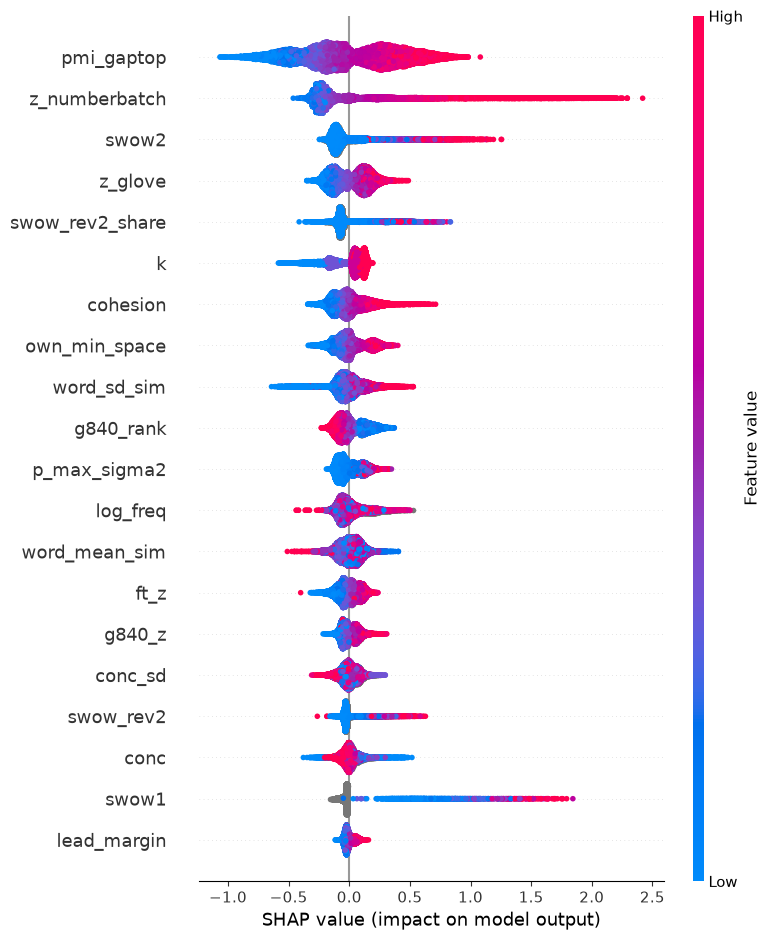

In [4]:
shap.summary_plot(sv, Xs, feature_names=names, max_display=20, show=False)
plt.tight_layout(); plt.show()

## By feature block

The ablation in `docs/log.md` measured blocks by retraining without them. SHAP
measures something different -- how much the fitted model *uses* each block --
and the two can disagree when features are redundant: a block can be heavily
used and still be ablation-null, because a dropped feature's information is
recoverable from its correlates.

  block              n  sum |SHAP|   share  per feature
  nb                11      0.8507   36.0%       0.0773
  pmi                1      0.3292   13.9%       0.3292
  spaces             4      0.2564   10.9%       0.0641
  extraspaces        5      0.2381   10.1%       0.0476
  swowrev            4      0.2114    9.0%       0.0528
  norms              4      0.2027    8.6%       0.0507
  swow               3      0.1947    8.2%       0.0649
  wordnet            2      0.0562    2.4%       0.0281
  entity             2      0.0204    0.9%       0.0102


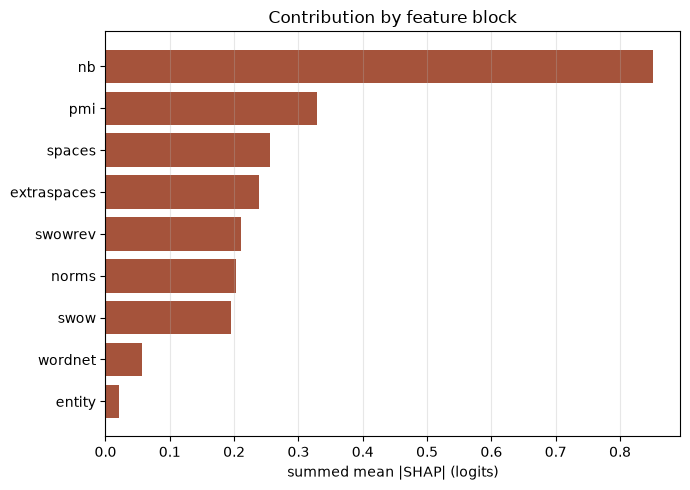

In [5]:
# Kept in step with scripts/pipeline/train_listener.py's FEATURE_BLOCKS, which
# is what the ablations select on -- if the two drift, SHAP shares and ablation
# deltas stop describing the same groups.
import sys; sys.path.insert(0, "..")
sys.argv = ["x"]
from scripts.pipeline.train_listener import FEATURE_BLOCKS as BLOCKS
tot = mean_abs.sum()
rows = sorted(((b, sum(mean_abs[names.index(f)] for f in fs), len(fs))
               for b, fs in BLOCKS.items()), key=lambda r: -r[1])
print(f"  {'block':16s} {'n':>3s} {'sum |SHAP|':>11s} {'share':>7s} {'per feature':>12s}")
for b, v, n in rows:
    print(f"  {b:16s} {n:3d} {v:11.4f} {v/tot:7.1%} {v/n:12.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([r[0] for r in rows][::-1], [r[1] for r in rows][::-1], color="#a5533b")
ax.set_xlabel("summed mean |SHAP| (logits)"); ax.grid(axis="x", alpha=.3)
ax.set_title("Contribution by feature block")
plt.tight_layout(); plt.show()

## SHAP vs LightGBM's own gain importance

Gain counts how much each split improved the objective, which rewards features
used early and often on large nodes. They should broadly agree; where they do
not, gain is usually the less trustworthy of the two.

In [6]:
gain = bst.feature_importance("gain")
rs = {n: i for i, n in enumerate(sorted(names, key=lambda n: -mean_abs[names.index(n)]))}
rg = {n: i for i, n in enumerate(sorted(names, key=lambda n: -gain[names.index(n)]))}
print(f"  {'feature':22s} {'SHAP rank':>10s} {'gain rank':>10s} {'shift':>6s}")
for n in sorted(names, key=lambda n: rs[n]):
    print(f"  {n:22s} {rs[n]+1:10d} {rg[n]+1:10d} {rg[n]-rs[n]:+6d}")

  feature                 SHAP rank  gain rank  shift
  pmi_gaptop                      1          4     +3
  z_numberbatch                   2          1     -1
  swow2                           3          7     +4
  z_glove                         4          9     +5
  swow_rev2_share                 5          5     +0
  k                               6         21    +15
  cohesion                        7         16     +9
  own_min_space                   8          3     -5
  word_sd_sim                     9          8     -1
  g840_rank                      10         12     +2
  p_max_sigma2                   11         11     +0
  log_freq                       12         10     -2
  word_mean_sim                  13         14     +1
  ft_z                           14         13     -1
  g840_z                         15         19     +4
  conc_sd                        16         15     -1
  swow_rev2                      17         22     +5
  conc                      

## Dependence: the analytic prior and the association signal

`p_max_sigma2` is the Gaussian model's own prediction, included so the trees
only have to learn where it is *wrong*. `swow2` is the two-hop human
association strength. Both are the interesting ones to see shaped.

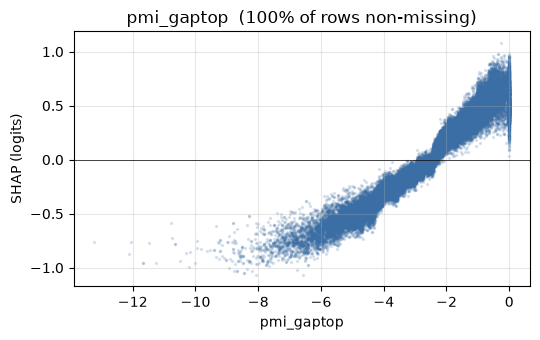

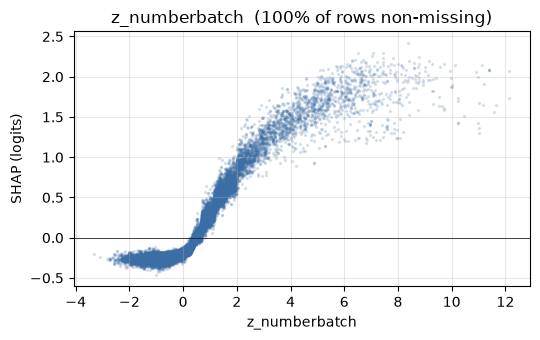

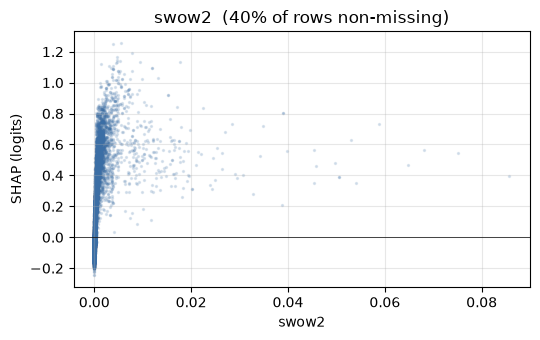

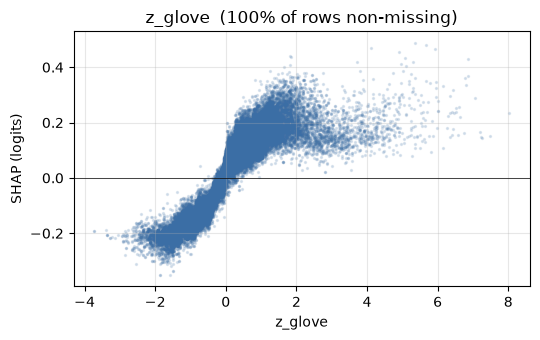

In [7]:
# Picked from what survives the prune rather than hard-coded to a feature set
# that has moved three times: the top four by mean |SHAP|.
for feat in [names[i] for i in np.argsort(-mean_abs)[:4]]:
    j = names.index(feat)
    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    ok = np.isfinite(Xs[:, j])
    ax.scatter(Xs[ok, j], sv[ok, j], s=2, alpha=.15, color="#3b6ea5")
    ax.axhline(0, color="k", lw=.5)
    ax.set_xlabel(feat); ax.set_ylabel("SHAP (logits)")
    ax.set_title(f"{feat}  ({ok.mean():.0%} of rows non-missing)")
    ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## Does the model lean on different features at step 1 vs later?

Step 1 is the decision the spymaster actually depends on; later steps were
measured as near-noise (`docs/log.md`). If the fitted model is spending
capacity differently there, it shows up here.

In [8]:
ev = np.repeat(np.arange(len(groups)), groups)[idx]
s1 = step[ev] == 0
a1, a2 = np.abs(sv[s1]).mean(axis=0), np.abs(sv[~s1]).mean(axis=0)
o = np.argsort(-(a1 + a2))[:15]
print(f"  {'feature':22s} {'step 1':>8s} {'step 2+':>8s} {'ratio':>7s}")
for i in o:
    print(f"  {names[i]:22s} {a1[i]:8.4f} {a2[i]:8.4f} {a1[i]/max(a2[i],1e-9):7.2f}")

  feature                  step 1  step 2+   ratio
  pmi_gaptop               0.3371   0.3232    1.04
  z_numberbatch            0.3352   0.2648    1.27
  swow2                    0.1508   0.1401    1.08
  z_glove                  0.1276   0.1276    1.00
  swow_rev2_share          0.1306   0.1210    1.08
  k                        0.1421   0.0940    1.51
  cohesion                 0.0983   0.1047    0.94
  own_min_space            0.0955   0.0942    1.01
  word_sd_sim              0.0911   0.0911    1.00
  g840_rank                0.0851   0.0907    0.94
  p_max_sigma2             0.0865   0.0750    1.15
  log_freq                 0.0786   0.0786    1.00
  word_mean_sim            0.0698   0.0727    0.96
  ft_z                     0.0692   0.0690    1.00
  g840_z                   0.0549   0.0556    0.99
